# Classical Baselines for RPS Prediction

This notebook compares four classical (non-learned) methods against the
trained **SimpleConv** neural network on DREGON-LM test samples:

1. **pyin** – single-$f_0$ tracker (librosa.pyin)
2. **Cepstral** – real-cepstrum peak picking + greedy multi-rotor extension
3. **HPS** – Harmonic Product Spectrum + greedy extension
4. **Matched Filter** – harmonic-comb template correlation + greedy extension
5. **SimpleConv** – learned baseline (1 M params)

All classical methods operate on the STFT magnitude spectrum of the mixture.
The greedy multi-rotor extension finds the strongest rotor, suppresses its
harmonic bins, and repeats up to four times.

In [1]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
#import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import librosa
import scipy.io

from classical_rps_predictors import (
    pyin_single_f0,
    cepstral_tracker,
    hps_tracker,
    matched_filter_tracker,
    evaluate_predictions,
)
from train_rps_predictor import SimpleConv

print("Imports OK")

Imports OK


## Constants & helpers

In [43]:
SR = 16_000
N_FFT = 2048
HOP_LENGTH = 512
DATA_DIR = PROJECT_ROOT / "datasets/DREGON-LM-test/valid"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

METHODS = {
    "pyin": pyin_single_f0,
    "cepstral": cepstral_tracker,
    "hps": hps_tracker,
    "matched_filter": matched_filter_tracker,
}

METHOD_COLORS = {
    "gt": "#333333",
    "pyin": "#ff7f0e",
    "cepstral": "#2ca02c",
    "hps": "#d62728",
    "matched_filter": "#9467bd",
    "simple_conv": "#1f77b4",
}

ROTOR_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


def load_sample(sample_dir: Path):
    """Load audio and ground-truth RPS from a DREGON-LM test sample."""
    audio, sr = sf.read(sample_dir / "mixture.wav")
    gt_raw = np.load(sample_dir / "rps.npy")          # (4, T_motor)
    n_frames = len(audio) // HOP_LENGTH + 1
    gt = np.zeros((4, n_frames), dtype=np.float32)
    x_old = np.linspace(0, 1, gt_raw.shape[1])
    x_new = np.linspace(0, 1, n_frames)
    for r in range(4):
        gt[r] = np.interp(x_new, x_old, gt_raw[r])
    return audio.astype(np.float32), sr, gt


def load_simpleconv():
    """Load the trained SimpleConv model."""
    model = SimpleConv(n_fft=N_FFT, hop_length=HOP_LENGTH).to(DEVICE)
    ckpt = torch.load(
        PROJECT_ROOT / "results/rps_predictor/best.pt",
        map_location=DEVICE,
        weights_only=True,
    )
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    model.eval()
    return model


def simpleconv_predict(model, audio):
    """Run SimpleConv on a mono waveform and return (4, n_frames) numpy array."""
    x = torch.from_numpy(audio.astype(np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(x)
    return pred.cpu().numpy()[0]


def plot_sample_comparison(audio, gt, preds_dict, title, figsize=(9, 5.5)):
    """
    Plot spectrogram + mean-RPS traces for all methods.
    preds_dict : dict[str -> ndarray(4, T)]
    """
    duration = len(audio) / SR
    fig, axes = plt.subplots(2, 1, figsize=figsize,
                             gridspec_kw={"height_ratios": [1, 1], "hspace": 0.35})

    # --- spectrogram ---
    ax = axes[0]
    spec = np.abs(np.fft.rfft(
        np.lib.stride_tricks.sliding_window_view(audio, N_FFT)[::HOP_LENGTH] *
        np.hanning(N_FFT), axis=-1))
    log_mag = np.log1p(spec.T)
    ax.imshow(log_mag, origin="lower", aspect="auto",
              extent=[0, duration, 0, SR / 2 / 1000], cmap="magma")
    ax.set_ylim(0, 4)
    ax.set_ylabel("freq [kHz]")
    ax.set_title(title)
    ax.set_xticklabels([])
    ax.grid(False)

    # --- mean RPS traces ---
    ax = axes[1]
    t = np.linspace(0, duration, gt.shape[1])
    gt_mean = gt.mean(axis=0)
    ax.plot(t, gt_mean, ":", color=METHOD_COLORS["gt"], lw=1.2,
            label="GT (mean of 4 rotors)", alpha=0.7)

    print('okay?')
    for name, pred in preds_dict.items():
        pred_mean = pred.mean(axis=0)
        t_pred = np.linspace(0, duration, len(pred_mean))
        ax.plot(t_pred, pred_mean, "-", color=METHOD_COLORS[name], lw=1.0,
                label=name.replace("_", " "), alpha=0.85)

    ax.set_xlabel("time [s]")
    ax.set_ylabel("mean rotor speed [rev/s]")
    ax.set_xlim(0, duration)
    ax.legend(frameon=False, loc="upper right", fontsize=7, ncol=3)
    return fig


def plot_per_rotor_comparison(audio, gt, preds_dict, title, method_keys="simple_conv",
                                figsize=(9, 4)):
    """Detailed per-rotor plot for one chosen method vs GT."""
    if not isinstance(method_keys, list):
        method_keys = [method_keys]

    duration = len(audio) / SR
    num_axes = 1 + len(method_keys)
    fig, axes = plt.subplots(num_axes, 1, figsize=figsize,
                             gridspec_kw={"height_ratios": [1]*num_axes , "hspace": 0.35})

    # spectrogram
    ax = axes[0]
    spec = np.abs(np.fft.rfft(
        np.lib.stride_tricks.sliding_window_view(audio, N_FFT)[::HOP_LENGTH] *
        np.hanning(N_FFT), axis=-1))
    log_mag = np.log1p(spec.T)
    ax.imshow(log_mag, origin="lower", aspect="auto",
              extent=[0, duration, 0, SR / 2 / 1000], cmap="magma")
    ax.set_ylim(0, 4)
    ax.set_ylabel("freq [kHz]")
    ax.set_title(title)
    ax.set_xticklabels([])
    ax.grid(False)

    # per-rotor traces
    for i, method_key in enumerate(method_keys):
        ax = axes[1+i]
        t = np.linspace(0, duration, gt.shape[1])
        pred = preds_dict[method_key]
        min_len = min(gt.shape[1], pred.shape[1])
        t = t[:min_len]
        for r in range(4):
            ax.plot(t, gt[r, :min_len], ":", color=ROTOR_COLORS[r], lw=0.6, alpha=0.5)
            t_pred = np.linspace(0, duration, pred.shape[1])[:min_len]
            ax.plot(t_pred, pred[r, :min_len], "-", color=ROTOR_COLORS[r], lw=0.8,
                    alpha=0.75, label=f"R{r+1}")
        ax.set_xlabel("time [s]")
        ax.set_ylabel("rotor speed [rev/s]")
        ax.set_xlim(0, duration)
        ax.legend(title=method_key, frameon=False, loc="upper right", fontsize=7, ncol=4)
    return fig

print("Helpers defined")

Helpers defined


## Load model & select samples

In [26]:
model = load_simpleconv()
print(f"SimpleConv loaded on {DEVICE}")

# Pick a diverse set of samples (first 10 available)
sample_dirs = sorted(DATA_DIR.glob("sample_*"))[:10]
SAMPLE_IDS = [s.name for s in sample_dirs]
print(f"Selected {len(SAMPLE_IDS)} samples: {SAMPLE_IDS[:5]} ...")

SimpleConv loaded on cpu
Selected 10 samples: ['sample_00000', 'sample_00001', 'sample_00002', 'sample_00003', 'sample_00004'] ...


## Run all methods on every sample

In [27]:
results = []          # list of dicts, one per sample
all_preds = {}        # sample_id -> {method: pred_array}

for sample_dir in sample_dirs:
    sid = sample_dir.name
    audio, sr, gt = load_sample(sample_dir)

    sample_result = {"sample_id": sid}
    preds_for_sample = {}

    # Neural network
    sc_pred = simpleconv_predict(model, audio)
    preds_for_sample["simple_conv"] = sc_pred
    sample_result["simple_conv"] = evaluate_predictions(sc_pred, gt)

    # Classical methods
    for name, fn in METHODS.items():
        try:
            pred = fn(audio, sr)
            preds_for_sample[name] = pred
            sample_result[name] = evaluate_predictions(pred, gt)
        except Exception as e:
            print(f"  {sid} {name} FAILED: {e}")
            preds_for_sample[name] = np.zeros_like(gt)
            sample_result[name] = {"mse": np.nan, "mae": np.nan, "r2": np.nan}

    results.append(sample_result)
    all_preds[sid] = {"gt": gt, **preds_for_sample}
    print(f"Done {sid}")

print("\nAll samples evaluated.")

Done sample_00000
Done sample_00001
Done sample_00002
Done sample_00003
Done sample_00004
Done sample_00005
Done sample_00006
Done sample_00007
Done sample_00008
Done sample_00009

All samples evaluated.


## Metrics summary table

In [28]:
rows = []
for sid_data in results:
    sid = sid_data["sample_id"]
    for method in ["simple_conv", "pyin", "cepstral", "hps", "matched_filter"]:
        m = sid_data[method]
        rows.append({
            "sample": sid,
            "method": method,
            "mse": m["mse"],
            "mae": m["mae"],
            "r2": m["r2"],
        })

df = pd.DataFrame(rows)

# Aggregate across samples
summary = df.groupby("method")[["mse", "mae", "r2"]].agg(["mean", "std"]).round(2)
summary = summary.reindex(["simple_conv", "pyin", "cepstral", "hps", "matched_filter"])
display(summary)

# Also show per-sample MSE for quick inspection
pivot_mse = df.pivot(index="sample", columns="method", values="mse")
pivot_mse = pivot_mse[["simple_conv", "pyin", "cepstral", "hps", "matched_filter"]]
print("\nPer-sample MSE:")
display(pivot_mse.round(1))

mse            mae            r2        
                   mean     std   mean   std    mean     std
method                                                      
simple_conv        7.16   11.34   1.70  1.06   -1.20    3.65
pyin             623.11  608.95  22.08  8.22 -229.45  154.81
cepstral        1379.03  514.57  28.81  4.89 -600.26  362.57
hps              870.46  152.71  27.56  1.47 -438.82  255.23
matched_filter  1338.59  301.77  29.79  2.92 -666.20  384.96


Per-sample MSE:


method,simple_conv,pyin,cepstral,hps,matched_filter
sample,,,,,
sample_00000,1.4,389.6,1226.8,796.3,1336.6
sample_00001,2.8,362.3,1315.3,867.8,1227.4
sample_00002,38.0,2270.4,2819.7,1289.2,1935.0
sample_00003,2.1,886.7,1197.8,805.6,1194.4
sample_00004,1.2,390.4,1231.9,847.5,1075.7
sample_00005,3.9,161.2,1278.5,889.0,1344.3
sample_00006,2.0,600.1,1144.8,840.6,1120.4
sample_00007,1.9,366.9,1000.0,823.0,1017.2
sample_00008,6.0,398.3,1300.8,802.5,1337.4


## Plot mean-RPS comparison for first 6 samples

okay?
okay?
okay?
okay?
okay?
okay?


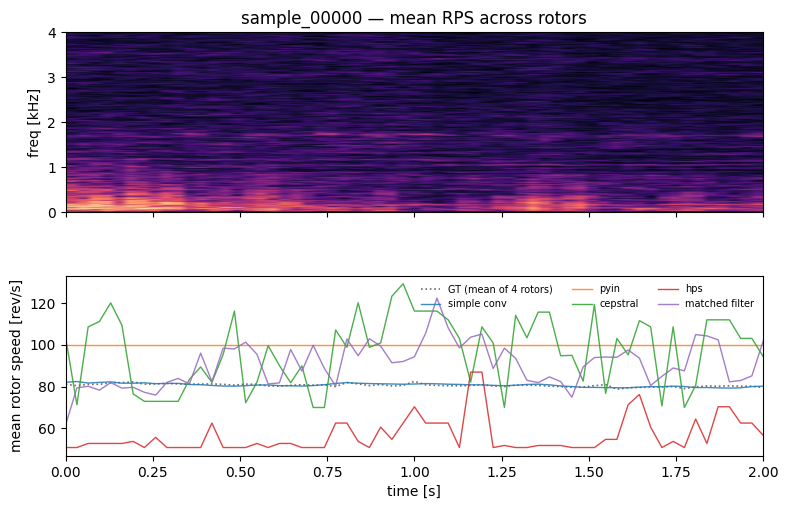

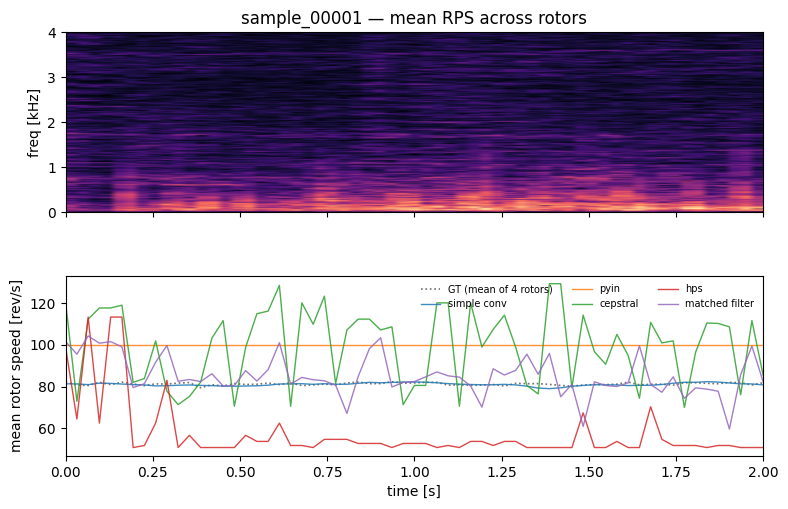

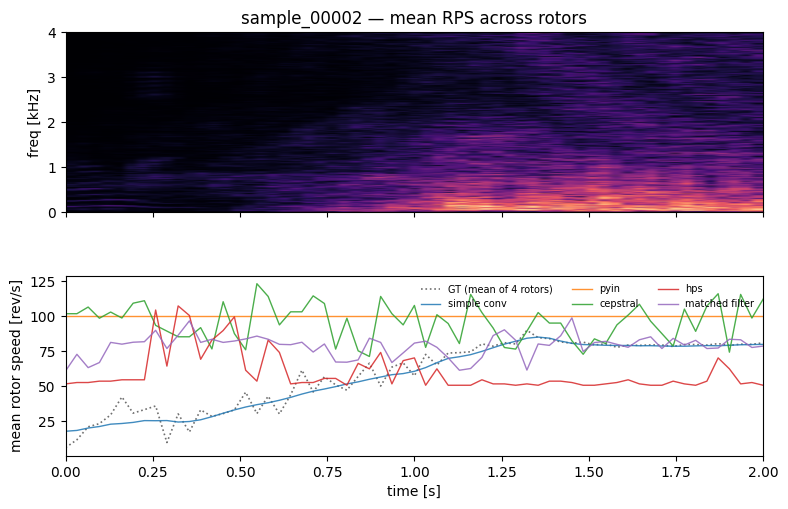

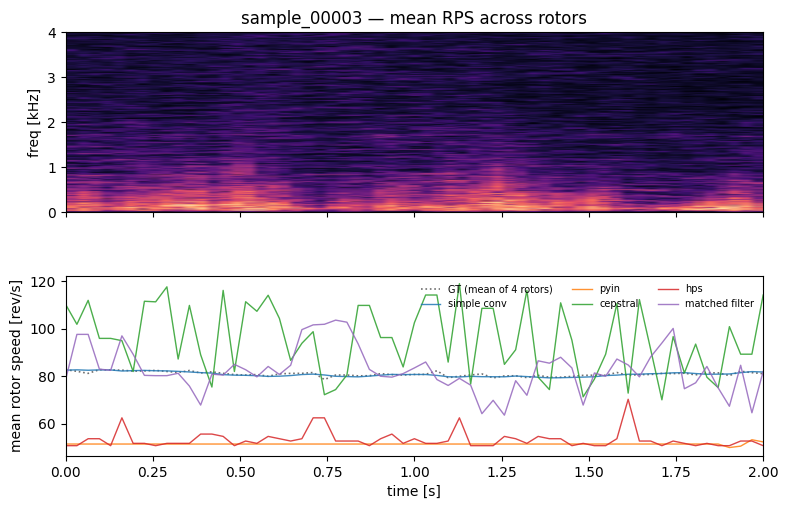

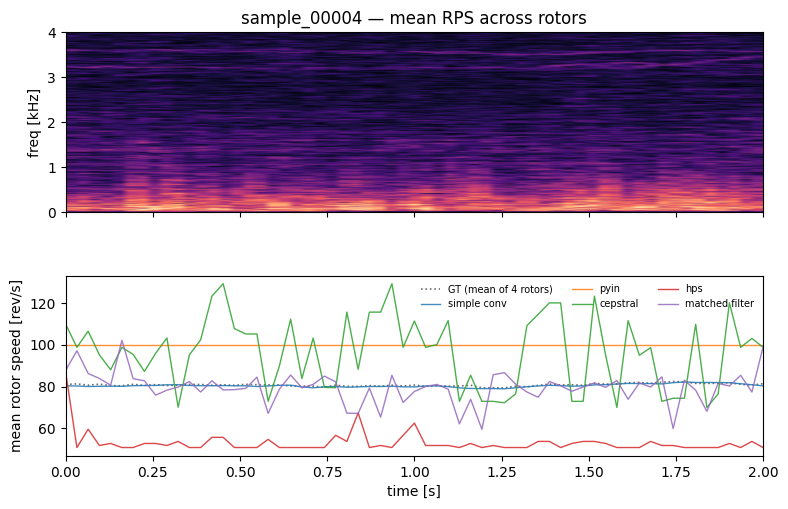

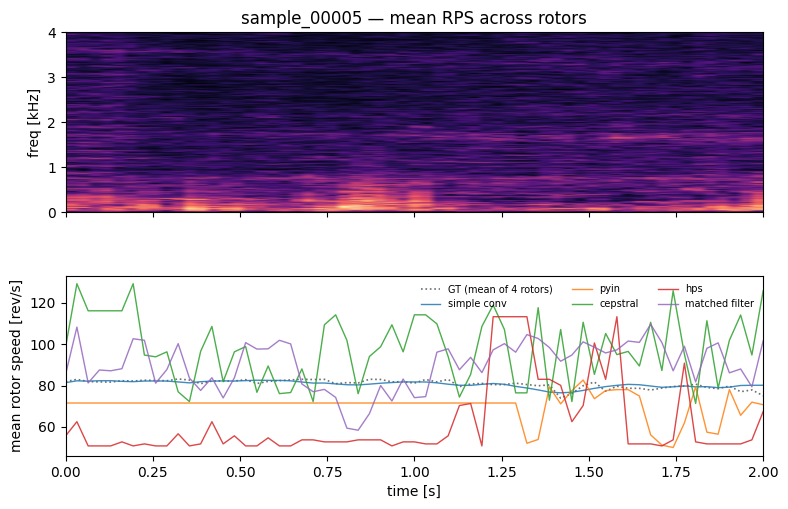

In [29]:
for sid in SAMPLE_IDS[:6]:
    audio, sr, gt = load_sample(DATA_DIR / sid)
    preds_dict = {k: v for k, v in all_preds[sid].items() if k != "gt"}
    fig = plot_sample_comparison(
        audio, gt, preds_dict,
        title=f"{sid} — mean RPS across rotors"
    )
    fig.show()
    #plt.close(fig)

## Detailed per-rotor plot: SimpleConv vs GT (sample 00005)

Sample ``00005`` is one of the few where pyin finds voiced frames, so it is a
good case for visual inspection.

In [40]:
def plot_method(method_keys, sample_ids=["sample_00005", "sample_00000"], **kwargs):
    for sid in sample_ids:
        if sid not in all_preds:
            continue
        audio, sr, gt = load_sample(DATA_DIR / sid)
        preds_dict = {k: v for k, v in all_preds[sid].items() if k != "gt"}
        fig = plot_per_rotor_comparison(
            audio, gt, preds_dict,
            title=f"{sid} — per-rotor predictions",
            method_keys=method_keys,
            **kwargs
        )
        plt.show()
        plt.close(fig)

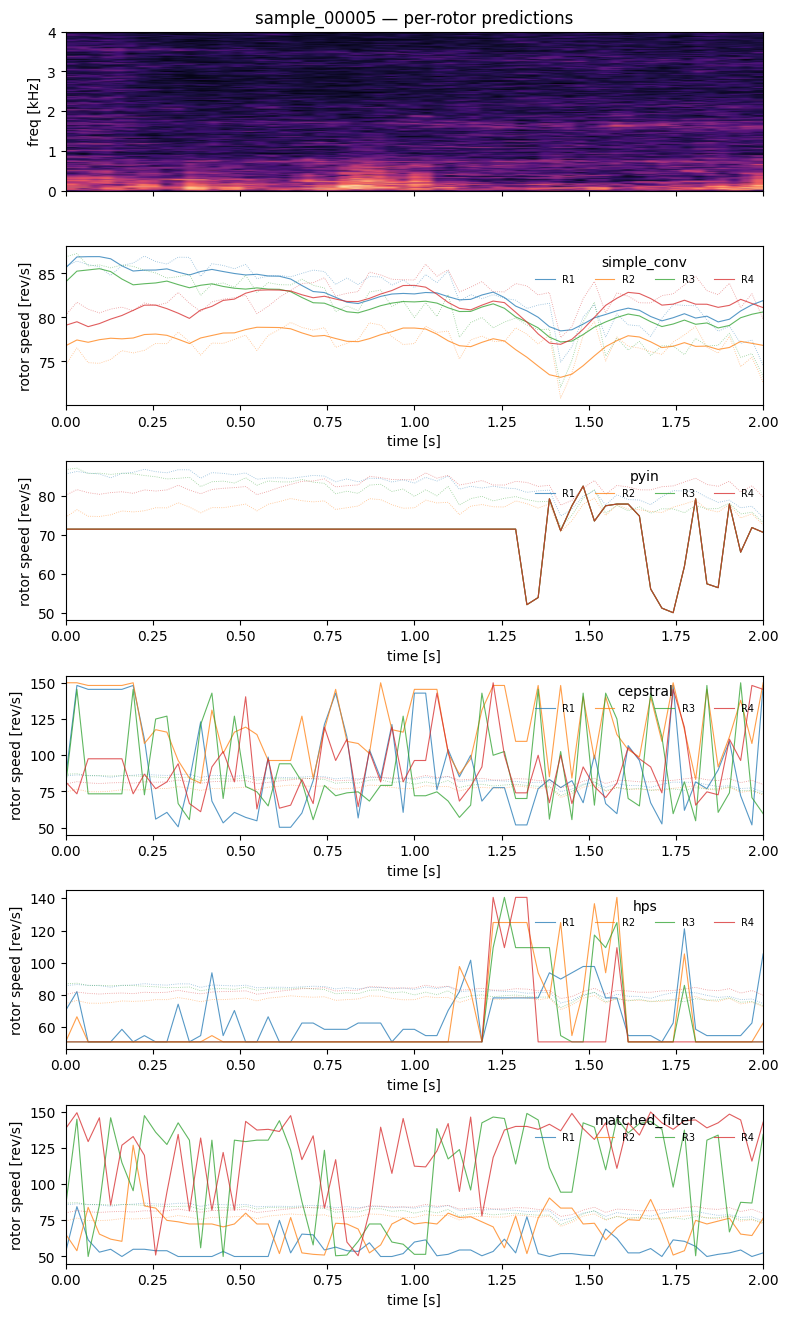

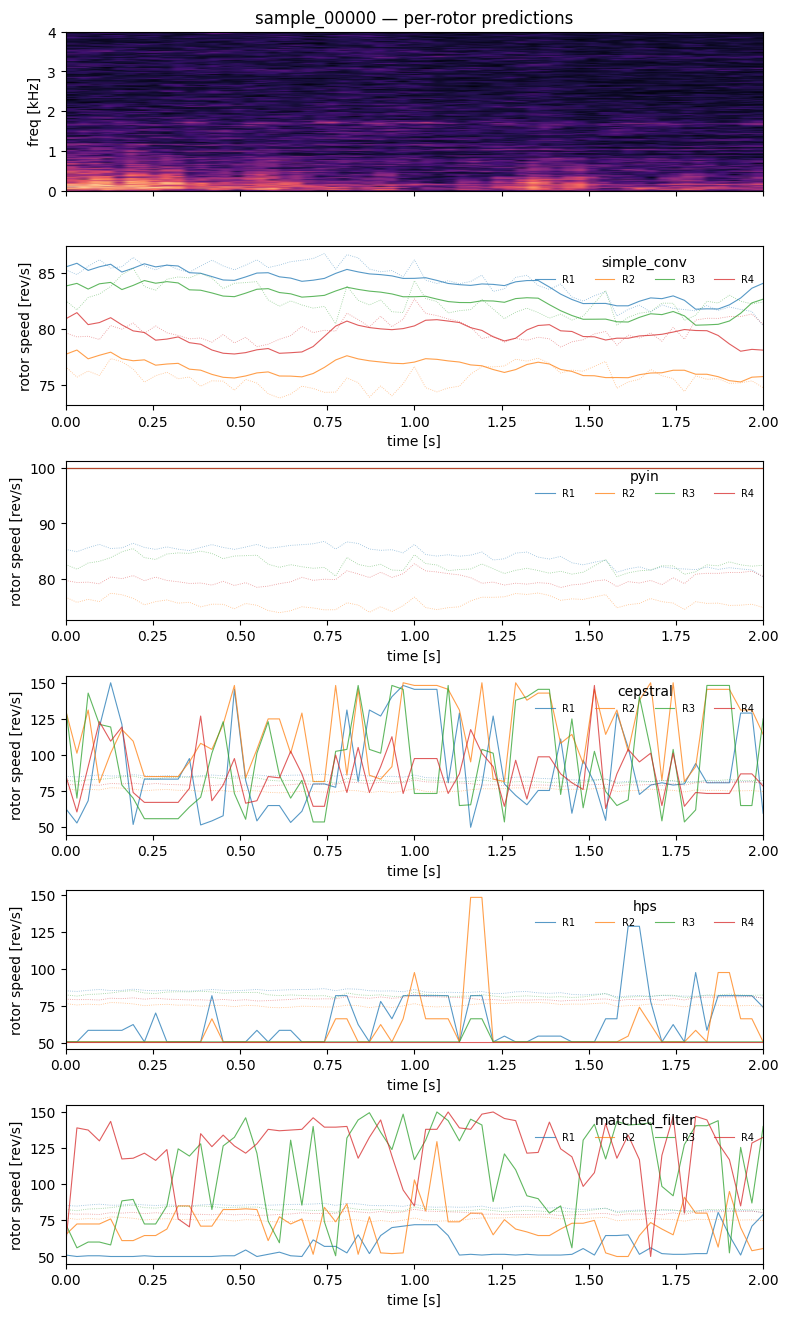

In [47]:
plot_method(['simple_conv']+list(METHODS.keys()), figsize=(9, 16))

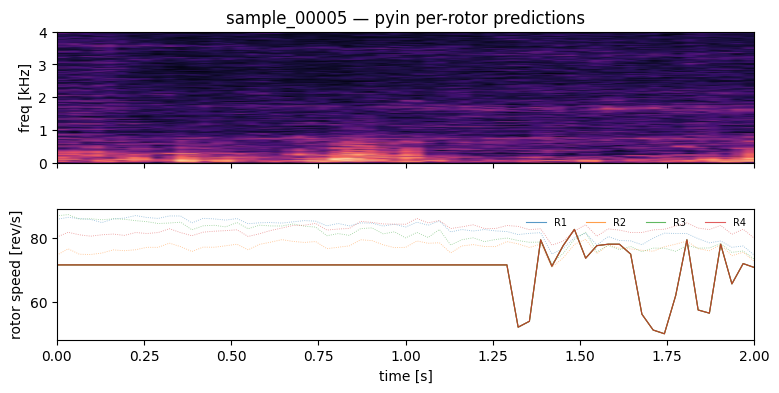

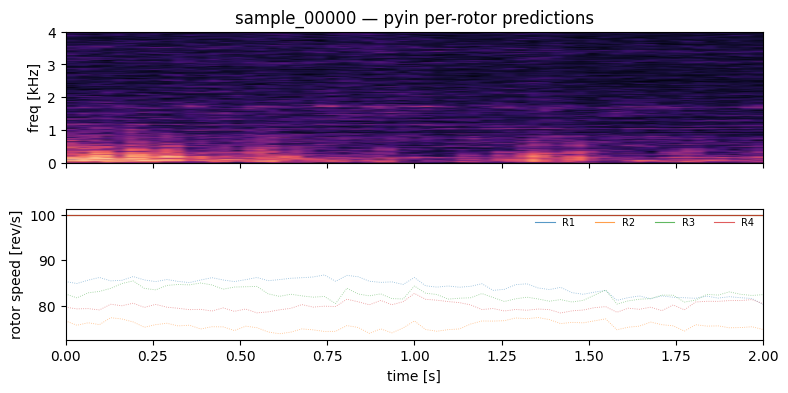

In [16]:
plot_method('pyin')

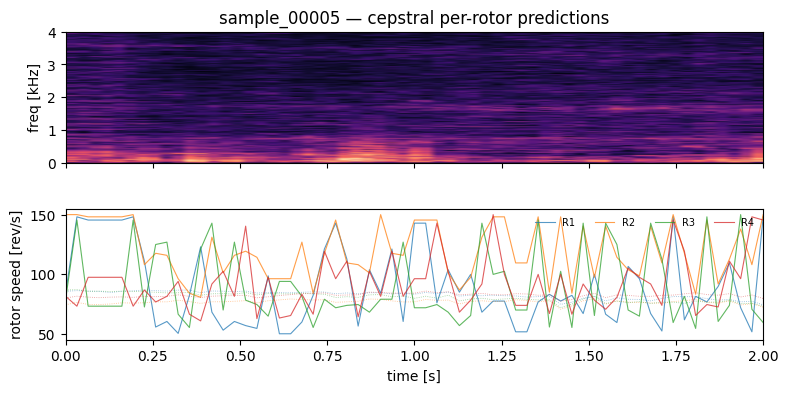

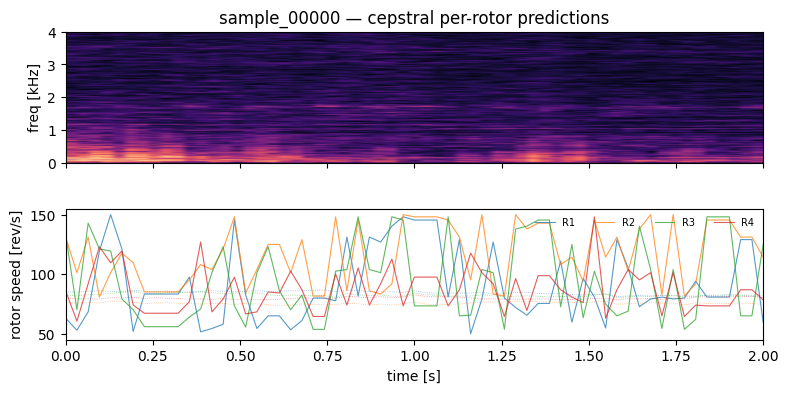

In [17]:
plot_method('cepstral')

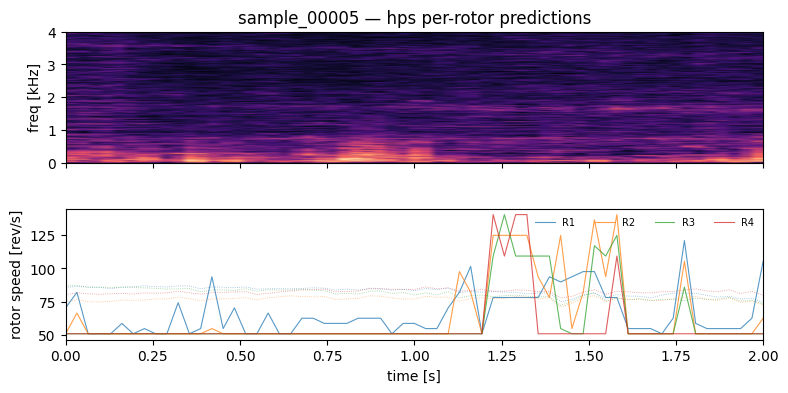

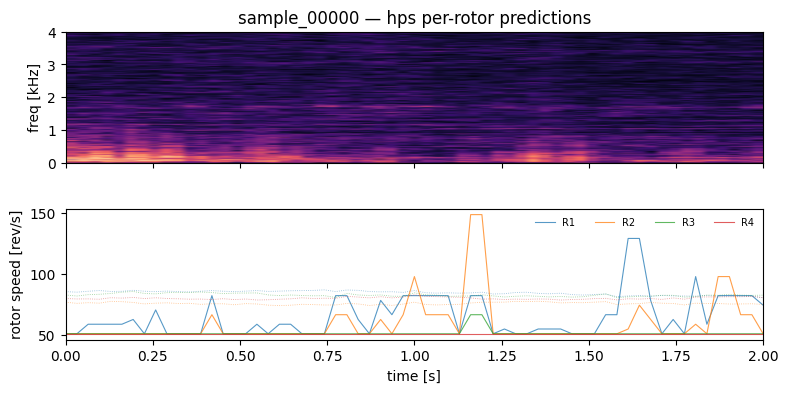

In [18]:
plot_method('hps')

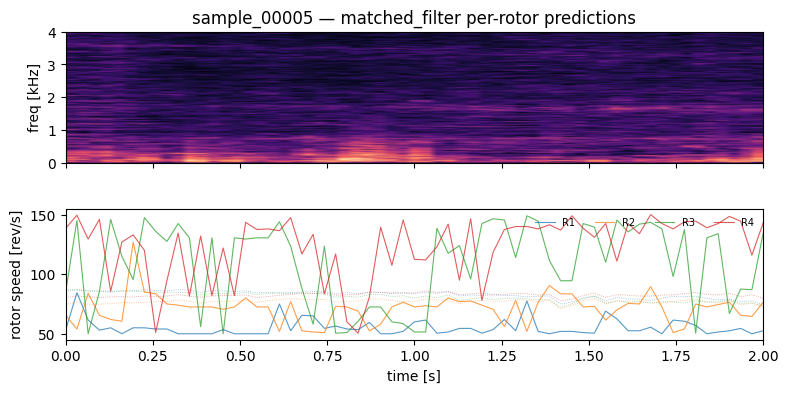

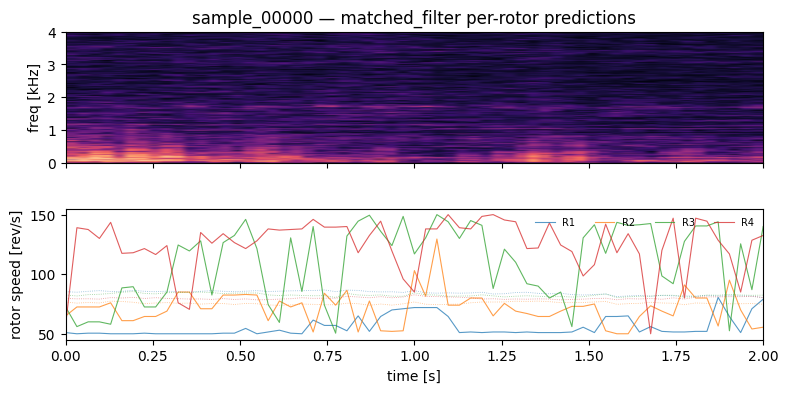

In [19]:
plot_method('matched_filter')

## Optional: evaluate on the high-SNR free-flight outlier clip

Classical methods should have an easier time on real high-SNR recordings.
The cell below extracts the landing-phase outlier clip from the DREGON
free-flight speech-high room1 recording and runs the same pipeline.

In [ ]:
# Extract outlier clip (same logic as make_figures.py / analyze_rps_high_snr.py)
DREGON_DIR = PROJECT_ROOT / "data/DREGON"
RECORDING = "DREGON_free-flight_speech-high_room1"
SAMPLE_DURATION = 8.224

rec_dir = DREGON_DIR / RECORDING
audio_full, sr44 = torchaudio.load(str(rec_dir / f"{RECORDING}.wav"))
audio_ts_mat = scipy.io.loadmat(rec_dir / f"{RECORDING}_audiots.mat")
audio_ts = audio_ts_mat["audio_timestamps"].flatten()
motor_mat = scipy.io.loadmat(rec_dir / f"{RECORDING}_motors.mat")
motor_data = motor_mat["motor"][0, 0]
measured = motor_data["measured"]
motor_ts = motor_data["timestamps"].flatten()
motor_sr = len(motor_ts) / (motor_ts[-1] - motor_ts[0])
recording_start = motor_ts[0]
recording_duration = motor_ts[-1] - motor_ts[0]

start_offset = 5.0
usable_duration = recording_duration - start_offset - SAMPLE_DURATION
step = usable_duration / 9
rel_time = start_offset + 9 * step

unix_time = recording_start + rel_time
audio_start_idx = int((unix_time - audio_ts[0]) * sr44)
end_sample = min(audio_start_idx + int(SAMPLE_DURATION * sr44), audio_full.shape[1])
audio_start_idx = min(audio_start_idx, audio_full.shape[1] - int(SAMPLE_DURATION * sr44))
audio_chunk = audio_full[:, audio_start_idx:end_sample]
resampler = torchaudio.transforms.Resample(orig_freq=sr44, new_freq=SR)
audio_mono = audio_chunk.mean(dim=0)
audio_16k = resampler(audio_mono.unsqueeze(0))
audio_max = audio_16k.abs().max()
if audio_max > 0:
    audio_16k = audio_16k / audio_max * 0.9
audio_np = audio_16k.numpy()[0]

# Ground truth
motor_rel_start = rel_time
motor_start_idx = np.searchsorted(motor_ts, recording_start + motor_rel_start) - 1
motor_end_idx = np.searchsorted(motor_ts, recording_start + motor_rel_start + SAMPLE_DURATION) + 1
rps_chunk = measured[motor_start_idx:motor_end_idx].T.astype(np.float32)
n_frames = len(audio_np) // HOP_LENGTH + 1
gt_outlier = np.zeros((4, n_frames), dtype=np.float32)
for r in range(4):
    motor_times = np.arange(rps_chunk.shape[1]) / motor_sr
    stft_times = np.arange(n_frames) * (HOP_LENGTH / SR)
    gt_outlier[r] = np.interp(stft_times, motor_times, rps_chunk[r])

# Run methods
outlier_preds = {"simple_conv": simpleconv_predict(model, audio_np)}
for name, fn in METHODS.items():
    outlier_preds[name] = fn(audio_np, SR)

fig = plot_sample_comparison(
    audio_np, gt_outlier, outlier_preds,
    title="Outlier clip (t≈38.6 s) — high-SNR free-flight landing"
)
plt.show()
plt.close(fig)

print("Outlier metrics:")
for name in ["simple_conv", "pyin", "cepstral", "hps", "matched_filter"]:
    m = evaluate_predictions(outlier_preds[name], gt_outlier)
    print(f"  {name:15s} MSE={m['mse']:7.2f}  MAE={m['mae']:5.2f}  R²={m['r2']:7.3f}")

## Interpretation checklist

- **pyin** often returns no voiced frames on low-SNR mixtures; when it does, it
  tracks a single (dominant) periodicity and cannot resolve the four rotors.
- **Cepstral / HPS / Matched Filter** all suffer from speech interference: the
  greedy suppression is too crude to separate four interleaved combs from speech
  formants, so the second, third and fourth rotor estimates are essentially noise.
- **SimpleConv** consistently tracks all four rotors because it has learned the
  *joint* statistics of the four-rotor comb shape and how it interacts with
  speech, across the full 2-second temporal context of the STFT frame sequence.
- On the **high-SNR outlier** all classical methods improve, but none of them
  correctly captures the landing-induced collapse to zero RPS because that regime
  is absent from their inductive bias (and from the training data of the neural
  network as well).